/Users/br4c3/Projects/linear-algebra-for-machine-and-deep-learning/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: divide by zero encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))
/Users/br4c3/Projects/linear-algebra-for-machine-and-deep-learning/.venv/lib/python3.9/site-packages/mpl_toolkits/mplot3d/art3d.py:1239: RuntimeWarning: overflow encountered in matmul
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


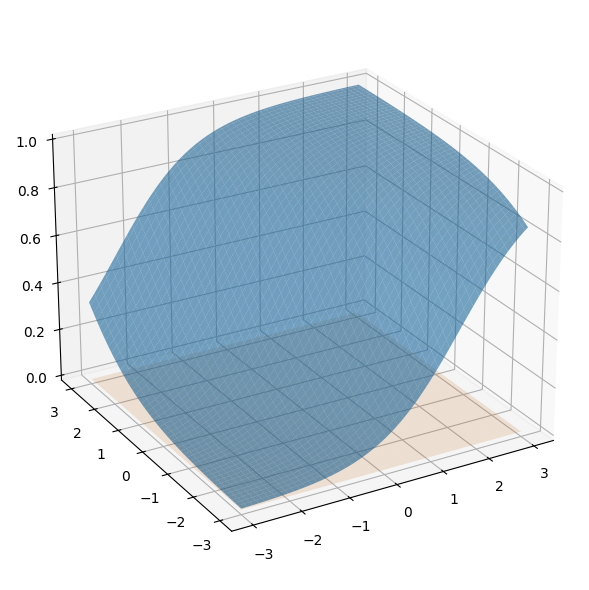

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

W = np.array(
    [1.2,  0.8]
)
b = 0.5

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)

X1, X2 = np.meshgrid(x1, x2)
Z = sigmoid(W[0] * X1 + W[1] * X2 + b)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X1, X2, Z, alpha=0.6
)

ax.plot_surface(
    X1,
    X2,
    np.zeros_like(Z),
    alpha=0.15
)
ax.view_init(
    elev=25,
    azim=-120
)

plt.tight_layout()
plt.show()

(100, 100)


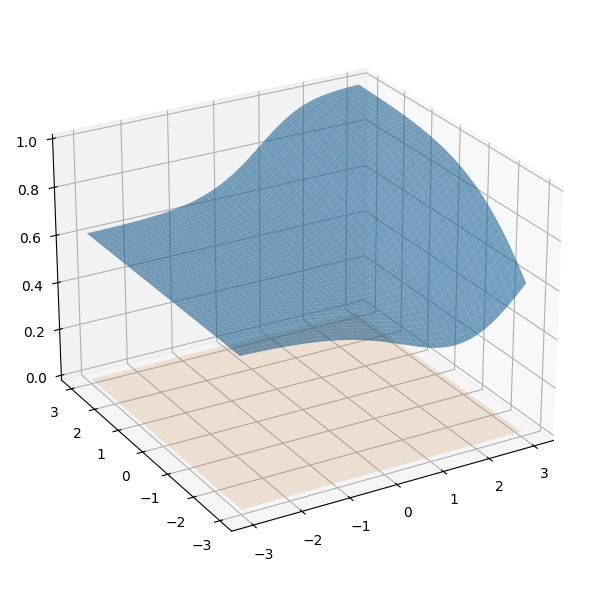

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1/(1+np.exp(-x))

W = np.array(
    [1.2,  0.8]
)
b = 0.5

x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)

X1, X2 = np.meshgrid(x1, x2)
Z1 = sigmoid(W[0] * X1 + W[1] * X2 + b)
Z = sigmoid(Z1[0] * X1 + Z1[1] * X2 + b)
print(Z.shape)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X1, X2, Z, alpha=0.6
)

ax.plot_surface(
    X1,
    X2,
    np.zeros_like(Z),
    alpha=0.15
)
ax.view_init(
    elev=25,
    azim=-120
)

plt.tight_layout()
plt.show()

W1 =
[[ 4.14696416 -3.78165075]
 [-4.13658588  4.37872893]]

b1 =
[[5.74608775 6.06212552]]

W2 =
[[-10.16696858]
 [-10.15211642]]

b2 =
[[14.93932306]]

Accuracy = 1.0


/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:162: RuntimeWarning: divide by zero encountered in matmul
  grid_Z1 = grid @ W1 + b1
/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:162: RuntimeWarning: overflow encountered in matmul
  grid_Z1 = grid @ W1 + b1
/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:162: RuntimeWarning: invalid value encountered in matmul
  grid_Z1 = grid @ W1 + b1
/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:165: RuntimeWarning: divide by zero encountered in matmul
  grid_Z2 = grid_H @ W2 + b2
/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:165: RuntimeWarning: overflow encountered in matmul
  grid_Z2 = grid_H @ W2 + b2
/var/folders/2p/hhtqy8b96_d6zjxc3jlbxhz80000gn/T/ipykernel_42849/2440968473.py:165: RuntimeWarning: invalid value encountered in matmul
  grid_Z2 = grid_H @ W2 + b2


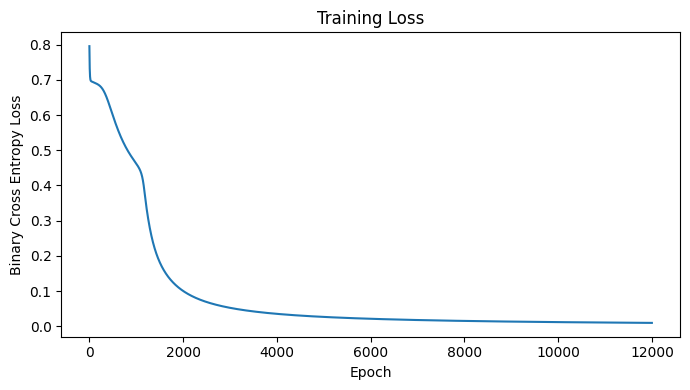

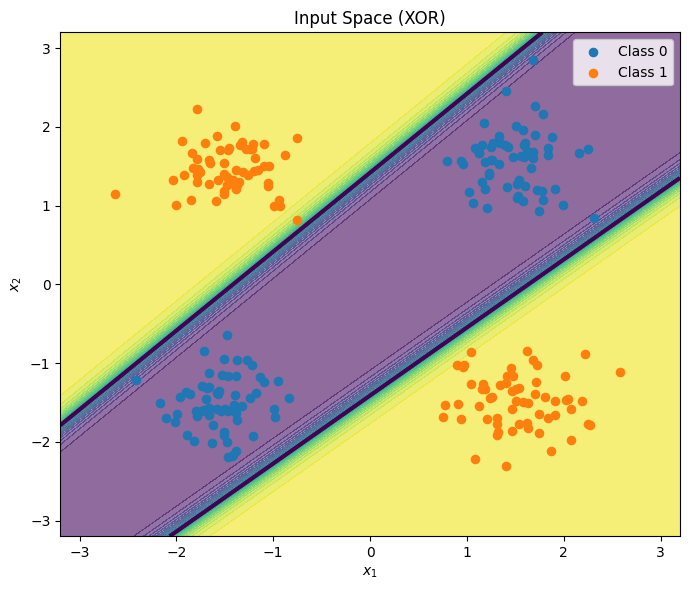

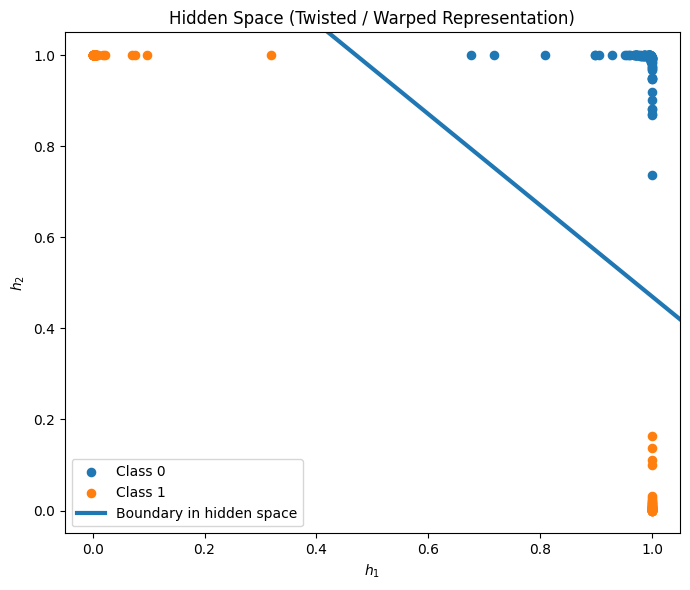

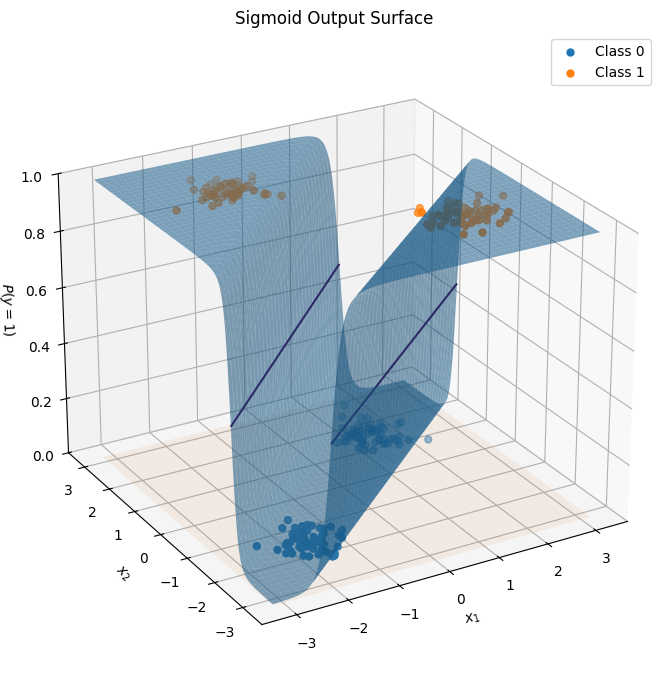

In [8]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# ============================================================
# 1. XOR-like dataset
# ============================================================

np.random.seed(42)

n_per_cluster = 60
noise = 0.35

# Class 0: bottom-left, top-right
class_0_a = (
    np.random.randn(n_per_cluster, 2) * noise
    + np.array([-1.5, -1.5])
)
class_0_b = (
    np.random.randn(n_per_cluster, 2) * noise
    + np.array([1.5, 1.5])
)
class_0 = np.vstack(
    [
        class_0_a,
        class_0_b,
    ]
)

# Class 1: top-left, bottom-right
class_1_a = (
    np.random.randn(n_per_cluster, 2) * noise
    + np.array([-1.5, 1.5])
)
class_1_b = (
    np.random.randn(n_per_cluster, 2) * noise
    + np.array([1.5, -1.5])
)
class_1 = np.vstack(
    [
        class_1_a,
        class_1_b,
    ]
)

X = np.vstack(
    [
        class_0,
        class_1,
    ]
)

y = np.vstack(
    [
        np.zeros((len(class_0), 1)),
        np.ones((len(class_1), 1)),
    ]
)

N = len(X)


# ============================================================
# 2. Model: 2 -> 2 -> 1
# ============================================================

hidden_dim = 2

W1 = np.random.randn(2, hidden_dim) * 0.8
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, 1) * 0.8
b2 = np.zeros((1, 1))

lr = 0.2
epochs = 12000

loss_history = []


# ============================================================
# 3. Training
# ============================================================

for epoch in range(epochs):
    # Forward
    Z1 = X @ W1 + b1
    H = sigmoid(Z1)

    Z2 = H @ W2 + b2
    y_hat = sigmoid(Z2)

    # Binary cross entropy
    eps = 1e-8
    loss = -np.mean(
        y * np.log(y_hat + eps)
        + (1 - y) * np.log(1 - y_hat + eps)
    )
    loss_history.append(loss)

    # Backprop
    dZ2 = y_hat - y
    dW2 = H.T @ dZ2 / N
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    dH = dZ2 @ W2.T
    dZ1 = dH * H * (1 - H)
    dW1 = X.T @ dZ1 / N
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1


# ============================================================
# 4. Final result
# ============================================================

Z1 = X @ W1 + b1
H = sigmoid(Z1)

Z2 = H @ W2 + b2
y_hat = sigmoid(Z2)

pred = (y_hat >= 0.5).astype(int)
acc = np.mean(pred == y)

print("W1 =")
print(W1)
print("\nb1 =")
print(b1)

print("\nW2 =")
print(W2)
print("\nb2 =")
print(b2)

print("\nAccuracy =", acc)


# ============================================================
# 5. Decision surface on input space
# ============================================================

x1 = np.linspace(-3.2, 3.2, 220)
x2 = np.linspace(-3.2, 3.2, 220)

X1, X2 = np.meshgrid(x1, x2)

grid = np.c_[
    X1.ravel(),
    X2.ravel(),
]

grid_Z1 = grid @ W1 + b1
grid_H = sigmoid(grid_Z1)

grid_Z2 = grid_H @ W2 + b2
grid_Y = sigmoid(grid_Z2).reshape(X1.shape)


# ============================================================
# 6. Plot 1: Loss
# ============================================================

plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()


# ============================================================
# 7. Plot 2: Input space
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X1,
    X2,
    grid_Y,
    levels=30,
    alpha=0.6,
)
plt.contour(
    X1,
    X2,
    grid_Y,
    levels=[0.5],
    linewidths=3,
)

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    s=35,
    label="Class 0",
)
plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    s=35,
    label="Class 1",
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Input Space (XOR)")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8. Plot 3: Hidden space
# ============================================================

plt.figure(figsize=(7, 6))

H0 = H[y[:, 0] == 0]
H1 = H[y[:, 0] == 1]

plt.scatter(
    H0[:, 0],
    H0[:, 1],
    s=35,
    label="Class 0",
)
plt.scatter(
    H1[:, 0],
    H1[:, 1],
    s=35,
    label="Class 1",
)

# Output layer decision boundary in hidden space:
# W2[0]*h1 + W2[1]*h2 + b2 = 0
h1_line = np.linspace(-0.1, 1.1, 200)

if abs(W2[1, 0]) > 1e-8:
    h2_line = -(
        W2[0, 0] * h1_line + b2[0, 0]
    ) / W2[1, 0]
    plt.plot(
        h1_line,
        h2_line,
        linewidth=3,
        label="Boundary in hidden space",
    )

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("$h_1$")
plt.ylabel("$h_2$")
plt.title("Hidden Space (Twisted / Warped Representation)")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. Plot 4: 3D output surface
# ============================================================

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X1,
    X2,
    grid_Y,
    alpha=0.55,
)

# z=0 plane
ax.plot_surface(
    X1,
    X2,
    np.zeros_like(grid_Y),
    alpha=0.08,
)

# data points
ax.scatter(
    class_0[:, 0],
    class_0[:, 1],
    np.zeros(len(class_0)),
    s=25,
    label="Class 0",
)
ax.scatter(
    class_1[:, 0],
    class_1[:, 1],
    np.ones(len(class_1)),
    s=25,
    label="Class 1",
)

# contour-like decision boundary at probability 0.5
ax.contour(
    X1,
    X2,
    grid_Y,
    levels=[0.5],
    zdir="z",
    offset=0.5,
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$P(y=1)$")
ax.set_zlim(0, 1)
ax.set_title("Sigmoid Output Surface")
ax.view_init(
    elev=25,
    azim=-120,
)
ax.legend()

plt.tight_layout()
plt.show()

w = [0.39225984 0.36383213]
b = -0.008294056735786915
Accuracy = 1.0


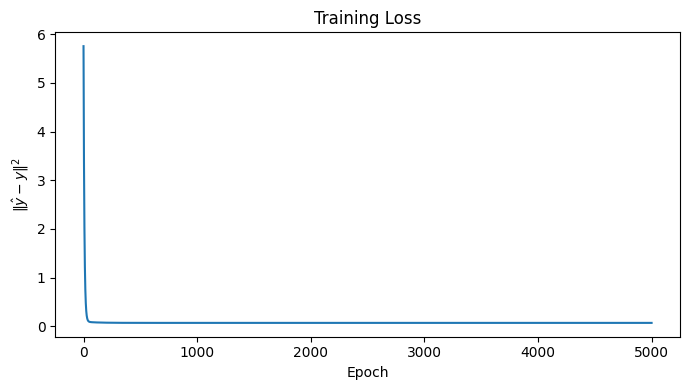

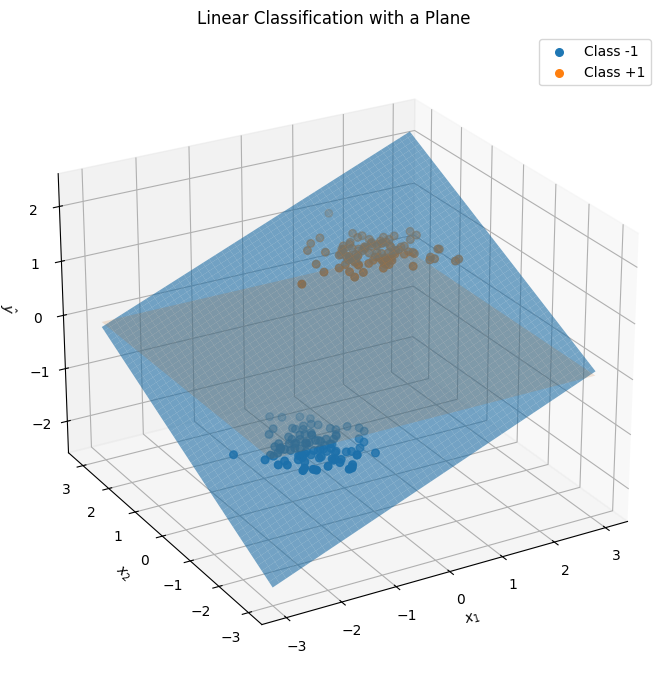

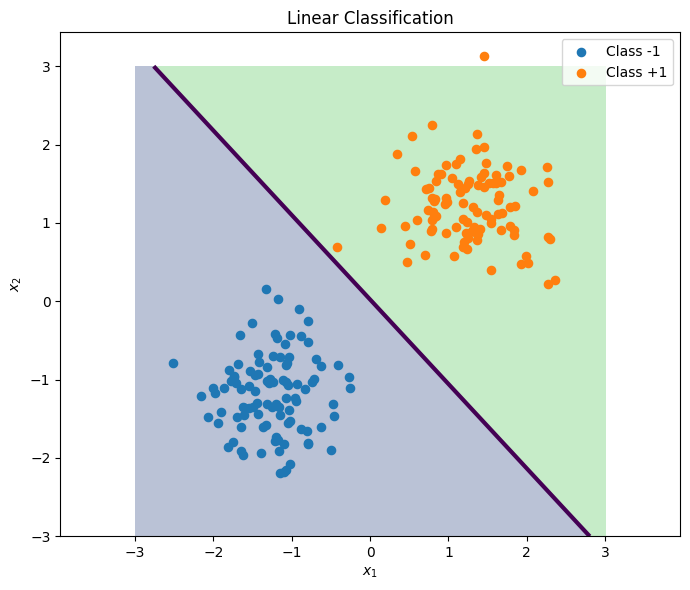

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Linearly separable dataset
# ============================================================

np.random.seed(42)

n = 100
noise = 0.5

# Class -1
class_0 = (
    np.random.randn(n, 2) * noise
    + np.array([-1.2, -1.2])
)

# Class +1
class_1 = (
    np.random.randn(n, 2) * noise
    + np.array([1.2, 1.2])
)

X = np.vstack(
    [
        class_0,
        class_1,
    ]
)

y = np.hstack(
    [
        -np.ones(len(class_0)),
        np.ones(len(class_1)),
    ]
)


# ============================================================
# 2. Single plane
#
# y_hat = w1*x1 + w2*x2 + b
# ============================================================

w = np.random.randn(2) * 0.5
b = 0.0

lr = 0.01
epochs = 5000

loss_history = []


# ============================================================
# 3. Training
#
# L = ||y_hat - y||^2
# ============================================================

for epoch in range(epochs):
    y_hat = X @ w + b

    loss = np.mean(
        (y_hat - y) ** 2
    )

    loss_history.append(loss)

    error = y_hat - y

    dw = (
        2
        * X.T
        @ error
        / len(X)
    )

    db = (
        2
        * np.mean(error)
    )

    w -= lr * dw
    b -= lr * db


# ============================================================
# 4. Prediction
# ============================================================

y_hat = X @ w + b

prediction = np.where(
    y_hat >= 0,
    1,
    -1,
)

accuracy = np.mean(
    prediction == y
)

print("w =", w)
print("b =", b)
print("Accuracy =", accuracy)


# ============================================================
# 5. Grid
# ============================================================

x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)

X1, X2 = np.meshgrid(
    x1,
    x2,
)

Z = (
    w[0] * X1
    + w[1] * X2
    + b
)


# ============================================================
# 6. Loss
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel(r"$\|\hat{y} - y\|^2$")
plt.title("Training Loss")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Learned plane
# ============================================================

fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d",
)

# Learned plane
ax.plot_surface(
    X1,
    X2,
    Z,
    alpha=0.6,
)

# z = 0 decision plane
ax.plot_surface(
    X1,
    X2,
    np.zeros_like(Z),
    alpha=0.15,
)

# Class -1
ax.scatter(
    class_0[:, 0],
    class_0[:, 1],
    np.full(len(class_0), -1),
    s=30,
    label="Class -1",
)

# Class +1
ax.scatter(
    class_1[:, 0],
    class_1[:, 1],
    np.full(len(class_1), 1),
    s=30,
    label="Class +1",
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel(r"$\hat{y}$")

ax.set_title(
    "Linear Classification with a Plane"
)

ax.view_init(
    elev=25,
    azim=-120,
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. 2D classification
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X1,
    X2,
    Z,
    levels=[
        -100,
        0,
        100,
    ],
    alpha=0.35,
)

# w1*x1 + w2*x2 + b = 0
plt.contour(
    X1,
    X2,
    Z,
    levels=[0],
    linewidths=3,
)

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    s=35,
    label="Class -1",
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    s=35,
    label="Class +1",
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.title(
    "Linear Classification"
)

plt.legend()
plt.axis("equal")

plt.tight_layout()
plt.show()

w = [ 0.0120092  -0.00725475]
b = 1.4091971108232786e-05
Accuracy = 0.5041666666666667


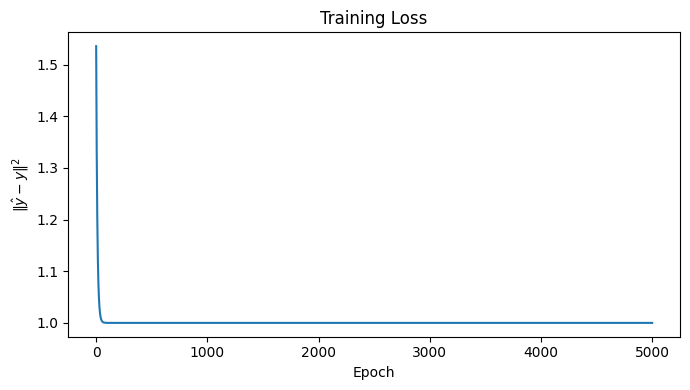

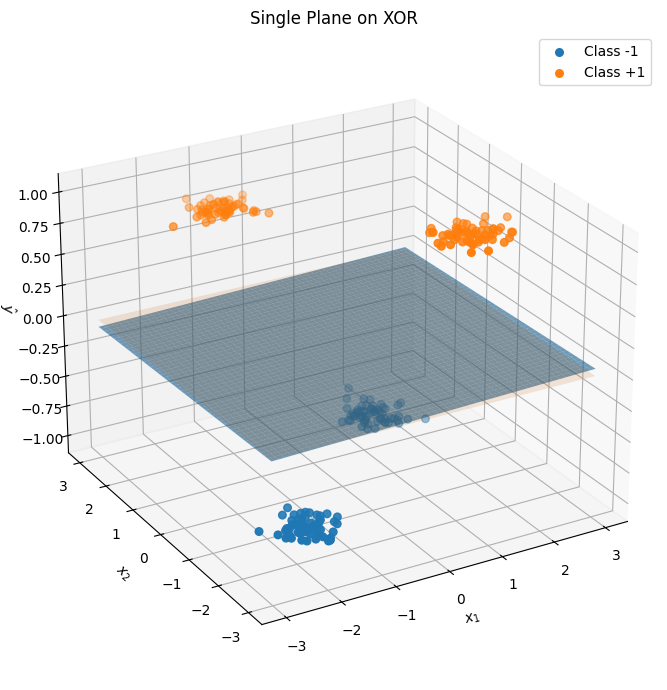

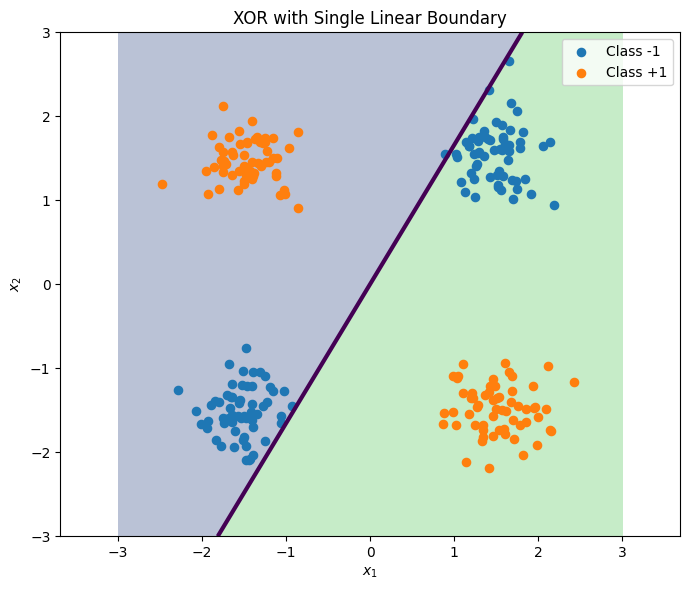

In [12]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. XOR dataset
# ============================================================

np.random.seed(42)

n = 60
noise = 0.3

# Class -1
# bottom-left, top-right
class_0 = np.vstack(
    [
        np.random.randn(n, 2) * noise + [-1.5, -1.5],
        np.random.randn(n, 2) * noise + [1.5, 1.5],
    ]
)

# Class +1
# top-left, bottom-right
class_1 = np.vstack(
    [
        np.random.randn(n, 2) * noise + [-1.5, 1.5],
        np.random.randn(n, 2) * noise + [1.5, -1.5],
    ]
)

X = np.vstack(
    [
        class_0,
        class_1,
    ]
)

y = np.hstack(
    [
        -np.ones(len(class_0)),
        np.ones(len(class_1)),
    ]
)


# ============================================================
# 2. Single plane
#
# y_hat = w1*x1 + w2*x2 + b
# ============================================================

w = np.random.randn(2) * 0.5
b = 0.0

lr = 0.01
epochs = 5000

loss_history = []


# ============================================================
# 3. Training
#
# L = ||y_hat - y||^2
# ============================================================

for epoch in range(epochs):
    y_hat = X @ w + b

    loss = np.mean(
        (y_hat - y) ** 2
    )

    loss_history.append(loss)

    error = y_hat - y

    dw = (
        2
        * X.T
        @ error
        / len(X)
    )

    db = 2 * np.mean(error)

    w -= lr * dw
    b -= lr * db


# ============================================================
# 4. Prediction
# ============================================================

y_hat = X @ w + b

prediction = np.where(
    y_hat >= 0,
    1,
    -1,
)

accuracy = np.mean(
    prediction == y
)

print("w =", w)
print("b =", b)
print("Accuracy =", accuracy)


# ============================================================
# 5. Grid
# ============================================================

x1 = np.linspace(-3, 3, 200)
x2 = np.linspace(-3, 3, 200)

X1, X2 = np.meshgrid(
    x1,
    x2,
)

Z = (
    w[0] * X1
    + w[1] * X2
    + b
)


# ============================================================
# 6. Loss
# ============================================================

plt.figure(figsize=(7, 4))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel(r"$\|\hat{y} - y\|^2$")
plt.title("Training Loss")

plt.tight_layout()
plt.show()


# ============================================================
# 7. Learned plane
# ============================================================

fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d",
)

# Learned plane
ax.plot_surface(
    X1,
    X2,
    Z,
    alpha=0.6,
)

# z = 0
ax.plot_surface(
    X1,
    X2,
    np.zeros_like(Z),
    alpha=0.15,
)

# Class -1
ax.scatter(
    class_0[:, 0],
    class_0[:, 1],
    np.full(len(class_0), -1),
    s=30,
    label="Class -1",
)

# Class +1
ax.scatter(
    class_1[:, 0],
    class_1[:, 1],
    np.full(len(class_1), 1),
    s=30,
    label="Class +1",
)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel(r"$\hat{y}$")

ax.set_title(
    "Single Plane on XOR"
)

ax.view_init(
    elev=25,
    azim=-120,
)

ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 8. 2D classification result
# ============================================================

plt.figure(figsize=(7, 6))

plt.contourf(
    X1,
    X2,
    Z,
    levels=[
        -100,
        0,
        100,
    ],
    alpha=0.35,
)

# Decision boundary
# w1*x1 + w2*x2 + b = 0
plt.contour(
    X1,
    X2,
    Z,
    levels=[0],
    linewidths=3,
)

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    s=35,
    label="Class -1",
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    s=35,
    label="Class +1",
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

plt.title(
    "XOR with Single Linear Boundary"
)

plt.legend()
plt.axis("equal")

plt.tight_layout()
plt.show()